In [1]:
import tensorflow_datasets as tfds

(train_dataset, val_dataset), info = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

In [2]:
class_names = info.features["label"].names
print(class_names)

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


In [3]:
import tensorflow as tf

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [4]:
train_dataset = (
    train_dataset
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_dataset
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [5]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels)

(16, 224, 224, 3)
tf.Tensor([0 4 4 3 3 2 2 3 3 4 0 2 0 2 0 1], shape=(16,), dtype=int64)


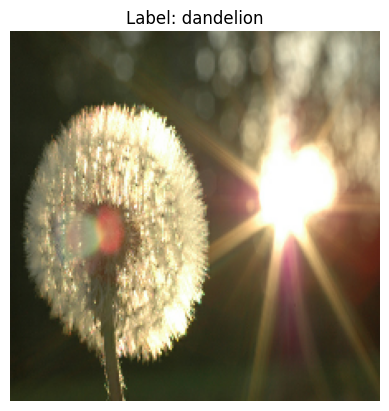

In [6]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):
    plt.imshow(images[0])
    plt.title("Label: " + class_names[labels[0]])
    plt.axis("off")

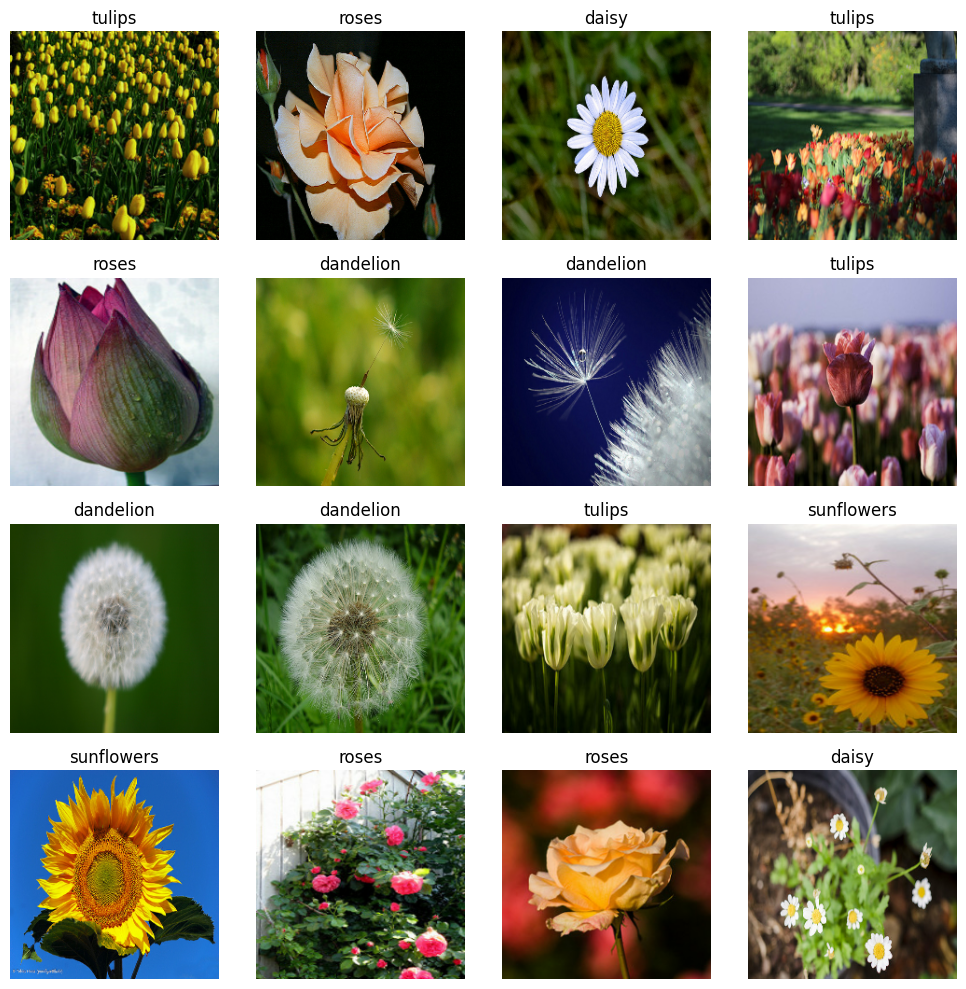

In [7]:
for images, labels in train_dataset.take(1):
  fig, axes = plt.subplots(4, 4, figsize=(10, 10))
  for i in range(16):
    ax = axes[i // 4, i % 4]
    ax.imshow(images[i])
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
  plt.tight_layout()
  plt.show()

In [8]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    keras.layers.Dense(len(class_names), activation = "softmax")
])

model.compile(
    optimizer = "adam",
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs = EPOCHS
)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.3518 - loss: 11.7861 - val_accuracy: 0.3379 - val_loss: 10.4530
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4142 - loss: 9.8237 - val_accuracy: 0.2834 - val_loss: 16.4537
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5000 - loss: 6.7753 - val_accuracy: 0.3379 - val_loss: 11.7989
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4731 - loss: 9.5285 - val_accuracy: 0.3665 - val_loss: 10.6950
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4874 - loss: 9.7964 - val_accuracy: 0.4455 - val_loss: 13.1148
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5201 - loss: 9.3432 - val_accuracy: 0.3924 - val_loss: 14.4733
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5811 - loss: 6.8175 - val_accuracy: 0.3869 - val_loss: 13.7747
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5634 - loss: 7.9071 -

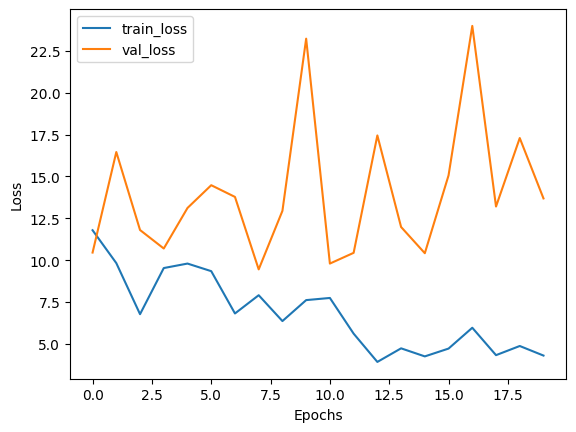

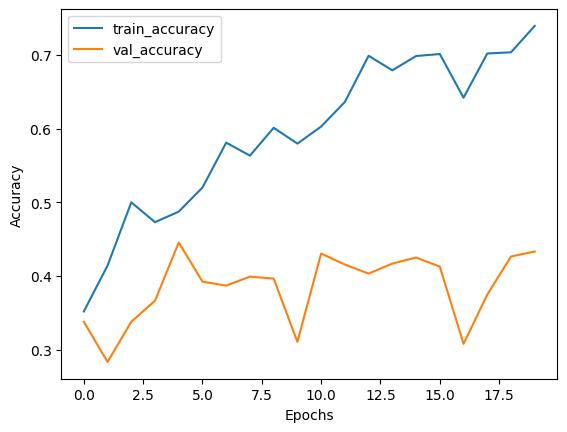

In [10]:
plt.plot(history.history["loss"], label = "train_loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label = "train_accuracy")
plt.plot(history.history["val_accuracy"], label = "val_accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


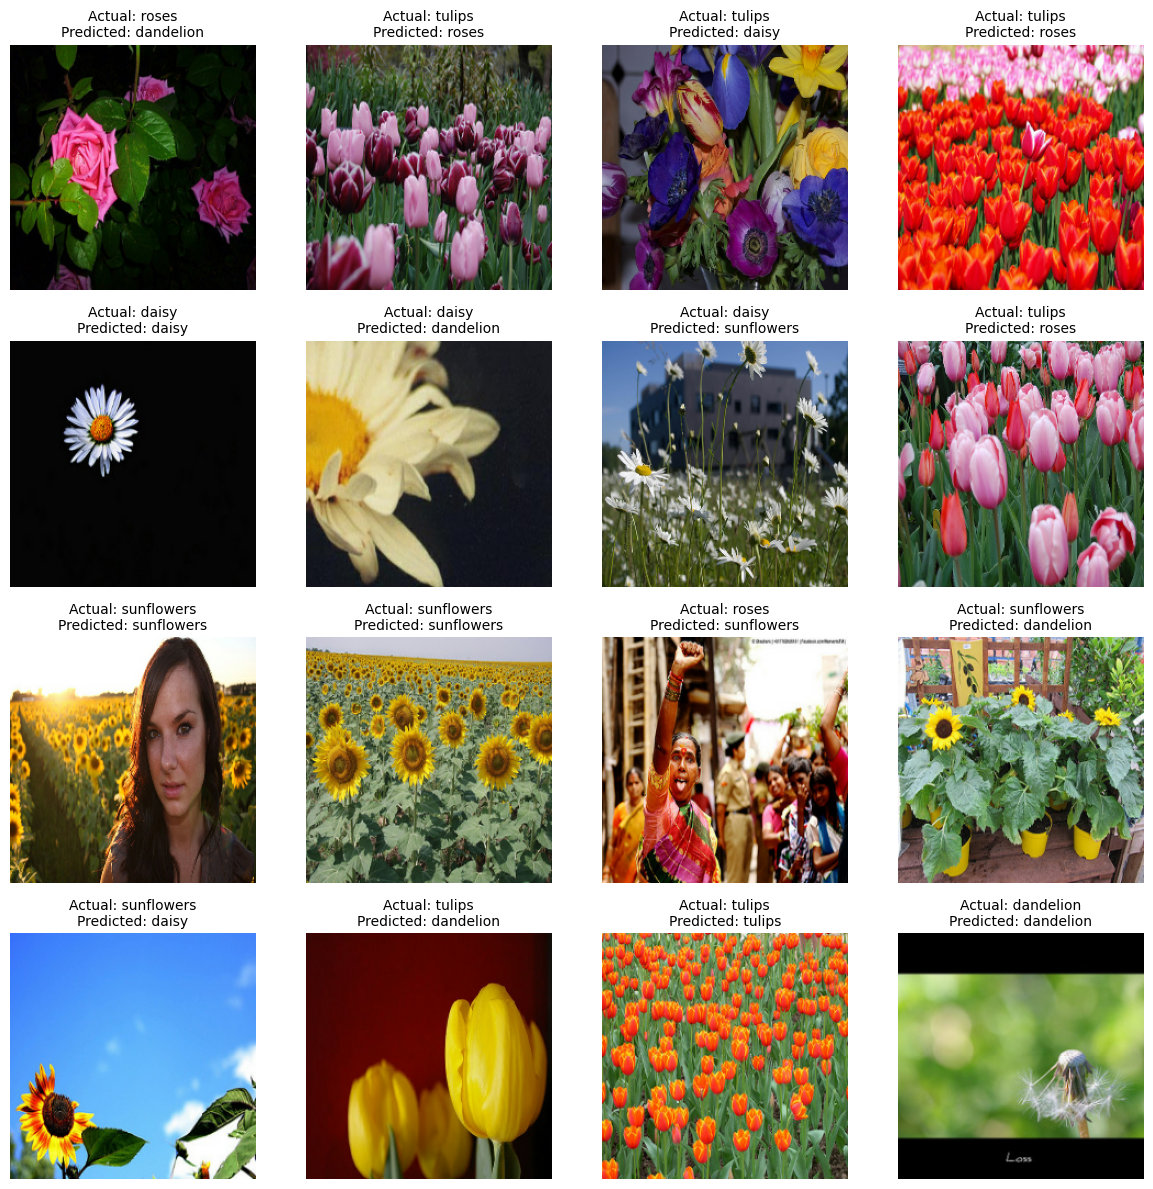

In [11]:
import math
import numpy as np

for images, labels in val_dataset.take(1):
  batch_prediction = model.predict(images)
  predicted_indices = np.argmax(batch_prediction, axis = 1)
  num_images = images.shape[0]

  num_cols = 4
  num_rows = math.ceil(num_images / num_cols)

  plt.figure(figsize=(12, 3 * num_rows))

  for i in range(num_images):
    plt.subplot(num_rows, num_cols, i + 1)

    plt.imshow(images[i].numpy())
    plt.axis('off')

    pred_class = class_names[predicted_indices[i]]
    actual_class = class_names[labels[i]]
    plt.title(f'Actual: {actual_class}\nPredicted: {pred_class}', fontsize=10)
  plt.tight_layout()
  plt.show()
